# Description

We evaluate the scalability of OPERON on the previously generated data with growing number of input variables.

Opening HDF5: scalability_experiment_data.h5
d_list = [2, 4, 8, 16, 32, 64]
Expressions = ['P3']
seeds (runs) = [0, 1, 2, 3, 4] (runs_per_d=5)

===== Expression: P3 =====
Loading data for Expression=P3, d=2 ...
Loaded: Xtr=(10000, 2), ytr=(10000,), Xte=(10000, 2), yte=(10000,)

RUN START | Expression=P3 | d=2 | run=1/5 | seed=0
  X_train: (10000, 2) | X_test: (10000, 2)
  operon_cfg: gens=100, pop=100, max_len=20, max_depth=10, opt=lm(50), ls_prob=0.05, lamarck=0.5, symbols='add,sub,mul,square,constant,variable', objectives=['mse', 'length'], select='mean_squared_error'
SymbolicRegressor kwargs: {'allowed_symbols': 'add,sub,mul,square,constant,variable', 'generations': 100, 'population_size': 100, 'max_length': 20, 'max_depth': 10, 'optimizer': 'lm', 'optimizer_iterations': 50, 'local_search_probability': 0.05, 'lamarckian_probability': 0.5, 'objectives': ['mse', 'length'], 'model_selection_criterion': 'mean_squared_error', 'random_state': 0}
fit() started ...
fit() finished
expr_str: 

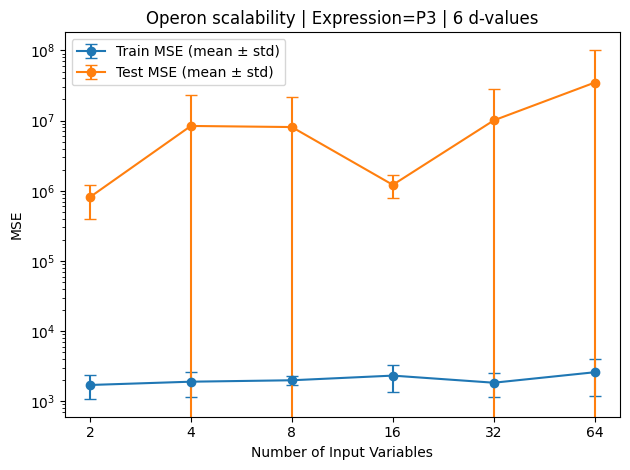


All done in 55.88 s


In [1]:
# operon_scalability_experiment.py
#
# - Runs Operon runs_per_d times per d
# - Saves per-run results to OperonCFG.report_csv_path
# - Plots mean ± std with uniformly spaced x ticks (labels are d)
# - y axis log scale if OperonCFG.y_log_scale is True
# - Console output cleaned per your requirements

from __future__ import annotations

import csv
import inspect
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from pyoperon.sklearn import SymbolicRegressor

from config.scalability_config import DataCFG, OperonCFG


def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    return float(np.mean((y_true - y_pred) ** 2))


def _build_operon_kwargs(seed: int) -> Dict[str, Any]:
    desired: Dict[str, Any] = {
        "allowed_symbols": OperonCFG.allowed_symbols,
        "symbols": OperonCFG.allowed_symbols,
        "function_set": OperonCFG.allowed_symbols,

        "generations": OperonCFG.generations,
        "population_size": OperonCFG.population_size,
        "max_length": OperonCFG.max_length,
        "max_depth": OperonCFG.max_depth,

        "optimizer": OperonCFG.optimizer,
        "optimizer_iterations": OperonCFG.optimizer_iterations,
        "local_search_probability": OperonCFG.local_search_probability,
        "lamarckian_probability": OperonCFG.lamarckian_probability,

        "objectives": list(OperonCFG.objectives),
        "model_selection_criterion": OperonCFG.model_selection_criterion,

        "random_state": seed,
        "seed": seed,

        "verbose": OperonCFG.verbose,
        "verbosity": OperonCFG.verbose,
        "progress": True,
    }

    sig = inspect.signature(SymbolicRegressor.__init__)
    supported = set(sig.parameters.keys())

    if "allowed_symbols" in supported:
        desired.pop("symbols", None)
        desired.pop("function_set", None)
    elif "symbols" in supported:
        desired.pop("allowed_symbols", None)
        desired.pop("function_set", None)
    elif "function_set" in supported:
        desired.pop("allowed_symbols", None)
        desired.pop("symbols", None)

    return {k: v for k, v in desired.items() if k in supported}


def _select_best_by_mse(reg: SymbolicRegressor, mse_key: str) -> Dict[str, Any]:
    if not hasattr(reg, "pareto_front_") or not reg.pareto_front_:
        raise RuntimeError("reg.pareto_front_ missing/empty after fit().")

    front: List[Dict[str, Any]] = reg.pareto_front_
    if not isinstance(front[0], dict) or mse_key not in front[0]:
        keys = sorted({k for dct in front if isinstance(dct, dict) for k in dct.keys()})
        raise RuntimeError(f"mse_key={mse_key!r} not in pareto_front_ keys={keys}")

    best = min(front, key=lambda d: d[mse_key])

    if best.get("model", None) is None and best.get("tree", None) is None:
        raise RuntimeError("Selected pareto entry has neither 'model' nor 'tree'.")

    return best


def _get_expression_string(reg: SymbolicRegressor, best_stats: Dict[str, Any]) -> str:
    if not hasattr(reg, "get_model_string"):
        raise RuntimeError("This pyoperon build has no get_model_string(). Cannot extract expression.")

    if best_stats.get("model", None) is not None:
        try:
            s = reg.get_model_string(best_stats["model"], OperonCFG.sym_decimals)
            if isinstance(s, str) and s.strip():
                return s
        except Exception:
            pass

    if best_stats.get("tree", None) is not None:
        s = reg.get_model_string(best_stats["tree"], OperonCFG.sym_decimals)
        if isinstance(s, str) and s.strip():
            return s

    raise RuntimeError("Failed to extract a non-empty model string.")


def _operon_string_to_sympy(expr_str: str, d: int) -> Tuple[sp.Expr, List[sp.Symbol]]:
    s = expr_str.replace("^", "**")

    xs = [sp.Symbol(f"X{i+1}", real=True) for i in range(d)]
    local_dict: Dict[str, Any] = {f"X{i+1}": xs[i] for i in range(d)}

    def square(u):
        return u ** 2

    local_dict["square"] = square

    expr = sp.sympify(s, locals=local_dict)
    return expr, xs


def _eval_sympy(expr: sp.Expr, xs: List[sp.Symbol], X: np.ndarray) -> np.ndarray:
    f = sp.lambdify(xs, expr, modules="numpy")
    cols = [np.asarray(X[:, i], dtype=np.float64) for i in range(len(xs))]
    y = f(*cols)
    return np.asarray(y, dtype=np.float64).reshape(-1)


def _print_run_header(Expression: str, d: int, seed: int, run_j: int, n_runs: int, Xtr: np.ndarray, Xte: np.ndarray) -> None:
    print("\n" + "=" * 110)
    print(f"RUN START | Expression={Expression} | d={d} | run={run_j+1}/{n_runs} | seed={seed}")
    print(f"  X_train: {Xtr.shape} | X_test: {Xte.shape}")
    print(
        "  operon_cfg: "
        f"gens={OperonCFG.generations}, pop={OperonCFG.population_size}, "
        f"max_len={OperonCFG.max_length}, max_depth={OperonCFG.max_depth}, "
        f"opt={OperonCFG.optimizer}({OperonCFG.optimizer_iterations}), "
        f"ls_prob={OperonCFG.local_search_probability}, lamarck={OperonCFG.lamarckian_probability}, "
        f"symbols='{OperonCFG.allowed_symbols}', objectives={list(OperonCFG.objectives)}, "
        f"select='{OperonCFG.model_selection_criterion}'"
    )
    print("=" * 110)


def _make_seeds() -> Tuple[int, ...]:
    n = int(getattr(OperonCFG, "runs_per_d", 5))
    cfg_seeds = tuple(getattr(OperonCFG, "seeds", ()))
    if len(cfg_seeds) >= n:
        return cfg_seeds[:n]
    return tuple(range(n))


def _aggregate(rows: List[Dict[str, Any]], Expression: str, d_list: List[int]) -> Dict[int, Dict[str, float]]:
    out: Dict[int, Dict[str, float]] = {}
    for d in d_list:
        sub = [r for r in rows if r["Expression"] == Expression and r["d"] == d]
        tr = np.array([r["train_mse"] for r in sub], dtype=np.float64)
        te = np.array([r["test_mse"] for r in sub], dtype=np.float64)
        out[d] = {
            "train_mean": float(tr.mean()),
            "train_std": float(tr.std(ddof=0)),
            "test_mean": float(te.mean()),
            "test_std": float(te.std(ddof=0)),
        }
    return out


def _plot_errorbars_uniform_x(Expression: str, agg: Dict[int, Dict[str, float]], d_list: List[int]) -> None:
    x_pos = np.arange(len(d_list), dtype=np.int32)

    tr_mean = np.array([agg[d]["train_mean"] for d in d_list], dtype=np.float64)
    tr_std = np.array([agg[d]["train_std"] for d in d_list], dtype=np.float64)
    te_mean = np.array([agg[d]["test_mean"] for d in d_list], dtype=np.float64)
    te_std = np.array([agg[d]["test_std"] for d in d_list], dtype=np.float64)

    plt.figure()
    plt.errorbar(x_pos, tr_mean, yerr=tr_std, fmt="-o", capsize=4, label="Train MSE (mean ± std)")
    plt.errorbar(x_pos, te_mean, yerr=te_std, fmt="-o", capsize=4, label="Test MSE (mean ± std)")

    if getattr(OperonCFG, "y_log_scale", True):
        plt.yscale("log")

    plt.xlabel(getattr(OperonCFG, "x_label", "Number of Input Variables"))
    plt.ylabel(getattr(OperonCFG, "y_label", "MSE"))
    plt.title(f"Operon scalability | Expression={Expression} | {len(d_list)} d-values")

    plt.xticks(x_pos, [str(d) for d in d_list])
    plt.legend()
    plt.tight_layout()
    plt.show()


def _write_report_csv(rows: List[Dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = [
        "Expression",
        "d",
        "run",
        "seed",
        "train_mse",
        "test_mse",
        "expr",
    ]

    with path.open("w", newline="", encoding="utf-8") as fp:
        w = csv.DictWriter(fp, fieldnames=fieldnames)
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in fieldnames})

    print(f"Saved per-run report: {str(path)}")


def main() -> None:
    t0_all = time.perf_counter()
    rows: List[Dict[str, Any]] = []

    h5_path = str(DataCFG.out_path)

    Expressions: Tuple[str, ...] = tuple(getattr(OperonCFG, "kinds", ()))
    if len(Expressions) == 0:
        Expressions = ("P3",)

    seeds = _make_seeds()
    n_runs = len(seeds)
    mse_key = getattr(OperonCFG, "model_selection_criterion", "mean_squared_error")
    report_csv_path = Path(getattr(OperonCFG, "report_csv_path", "reports/operon_scalability.csv"))

    print(f"Opening HDF5: {h5_path}")
    with h5py.File(h5_path, "r") as f:
        d_list = list(map(int, f.attrs["d_list"]))

        print(f"d_list = {d_list}")
        print(f"Expressions = {list(Expressions)}")
        print(f"seeds (runs) = {list(seeds)} (runs_per_d={n_runs})")

        for Expression in Expressions:
            print(f"\n===== Expression: {Expression} =====")
            for d in d_list:
                print(f"Loading data for Expression={Expression}, d={d} ...")

                Xtr = f[f"data/{Expression}/d{d}/train/X"][...].astype(np.float64, copy=False)
                ytr = f[f"data/{Expression}/d{d}/train/y"][...].astype(np.float64, copy=False).reshape(-1)

                Xte = f[f"data/{Expression}/d{d}/test/X"][...].astype(np.float64, copy=False)
                yte = f[f"data/{Expression}/d{d}/test/y"][...].astype(np.float64, copy=False).reshape(-1)

                print(f"Loaded: Xtr={Xtr.shape}, ytr={ytr.shape}, Xte={Xte.shape}, yte={yte.shape}")

                for run_j, seed in enumerate(seeds):
                    _print_run_header(Expression, d, seed, run_j, n_runs, Xtr, Xte)

                    kwargs = _build_operon_kwargs(seed=seed)
                    print(f"SymbolicRegressor kwargs: {kwargs}")

                    reg = SymbolicRegressor(**kwargs)

                    print("fit() started ...")
                    reg.fit(Xtr, ytr)
                    print("fit() finished")

                    best_stats = _select_best_by_mse(reg, mse_key=mse_key)

                    expr_str = _get_expression_string(reg, best_stats)
                    if getattr(OperonCFG, "print_best_expression", True):
                        print("expr_str:", expr_str)

                    expr_sym, xs_sym = _operon_string_to_sympy(expr_str, d=d)
                    expr_sym = sp.simplify(expr_sym)

                    yhat_tr = _eval_sympy(expr_sym, xs_sym, Xtr)
                    yhat_te = _eval_sympy(expr_sym, xs_sym, Xte)

                    tr_mse = mse(ytr, yhat_tr)
                    te_mse = mse(yte, yhat_te)

                    rows.append(
                        {
                            "Expression": Expression,
                            "d": int(d),
                            "run": int(run_j),
                            "seed": int(seed),
                            "train_mse": float(tr_mse),
                            "test_mse": float(te_mse),
                            "expr": expr_str,
                        }
                    )

                    print(
                        f"RESULT | Expression={Expression} | d={d:>3} | run={run_j+1}/{n_runs} | seed={seed} | "
                        f"train_mse={tr_mse:.6e} | test_mse={te_mse:.6e}"
                    )

    _write_report_csv(rows, report_csv_path)

    print("\n=== Summary (mean±std over runs) ===")
    for Expression in Expressions:
        d_list_sorted = sorted({r["d"] for r in rows if r["Expression"] == Expression})
        agg = _aggregate(rows, Expression=Expression, d_list=d_list_sorted)
        for d in d_list_sorted:
            a = agg[d]
            print(
                f"Expression={Expression} d={d:>3} | "
                f"train_mse={a['train_mean']:.6e}±{a['train_std']:.6e} | "
                f"test_mse={a['test_mean']:.6e}±{a['test_std']:.6e}"
            )
        _plot_errorbars_uniform_x(Expression=Expression, agg=agg, d_list=d_list_sorted)

    total_s = time.perf_counter() - t0_all
    print(f"\nAll done in {total_s:.2f} s")


if __name__ == "__main__":
    main()
